Number of iterations: 13 with tolerance: 1e-06
Final solution: 3.591064453125


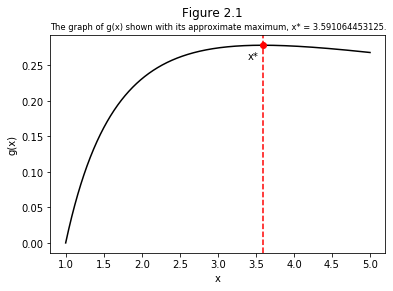

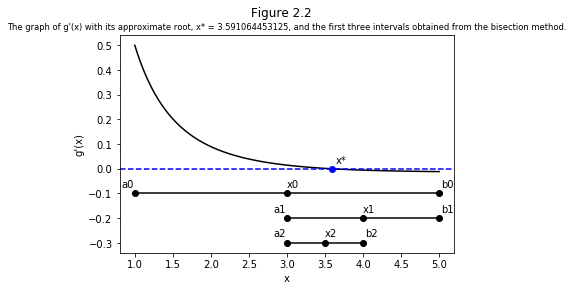

In [2]:
# MATH 472
# Homework 1
# Holly Bossart


import numpy as np
import matplotlib.pyplot as plt


# Function definitions
def g(x):
    return (np.log(x))/(1+x)

def gprime(x):
    return (1+(1/x) - np.log(x))/((1+x)**2)

def bisection(x, a, b, tol):
    num_iterations = 0
    max_iterations = 100
    a0 = a
    b0 = b
    
    # creating lists for these values for graphing purposes later
    a_list = [a]
    b_list = [b]
    x_list = [x]
    
    # check the condition holds to continue the loop
    while ((abs(gprime(x)) > tol) and (num_iterations < max_iterations)):
        
        # check that condition holds for intermediate value theorem
        if gprime(a)*gprime(b) > 0:
            print("Bisection method fails.")
            return
        
        # if this does not fail, then we can test other conditions given in book
        if gprime(a)*gprime(x) <= 0:
            a = a
            b = x
        elif gprime(a)*gprime(x) > 0:
            a = x
            b = b
        else:
            print("Something went wrong!")
            return
        
        # updating new x values in new interval
        x = (a+b)/2;
        num_iterations+=1;
        
        # storing our new a, b, and x values at the end of a list for graphing later
        a_list.append(a)
        b_list.append(b)
        x_list.append(x)
    
    # while loop has broken at this point in the code
    # we are either within the appropriate tolerance, or reached max iterations
    if num_iterations == max_iterations:
        print("Exceeded maximum number of iterations.")
        return
        
    # this is where we hope to be if bisection went well    
    else:
        print("Number of iterations: " + str(num_iterations) + " with tolerance: " + str(tol))
        print("Final solution: " + str(x))

        
        # plotting the first figure with g(x)
        x_vals = np.linspace(a0, b0, 1000)
        plt.figure()
        plt.plot(x_vals, g(x_vals), 'k')
        plt.axvline(x, color = 'r', linestyle = '--')
        plt.plot(x, g(x), 'ro')
        plt.annotate('x*', (x-0.2, g(x)-0.02))
        plt.xlabel('x')
        plt.ylabel('g(x)')
        plt.suptitle('Figure 2.1')
        plt.title('The graph of g(x) shown with its approximate maximum, x* = ' + str(x) + '.', fontsize = 'small')
        plt.show
        
        # plotting the second figure, g`(x) and intervals
        plt.figure()
        plt.plot(x_vals, gprime(x_vals), 'k')
        plt.axhline(0, color = 'b', linestyle = '--')
        plt.plot(x, gprime(x), 'bo')
        plt.annotate('x*', (x+0.05, gprime(x)+0.02))
        plt.xlabel('x')
        plt.ylabel('g\'(x)')
        plt.suptitle('Figure 2.2')
        plt.title('The graph of g\'(x) with its approximate root, x* = ' + str(x) + ', and the first three intervals obtained from the bisection method.', fontsize = 'small')
        
        ## we want to print out our intervals so we will go through each list we created to plot
        i = 0
        y_count = -0.1
        
        # just prints the first three intervals as specified by fig 2.2
        while i < 3:
            # plots horizontal lines
            plt.hlines(y=y_count, xmin=a_list[i], xmax=b_list[i])
            
            # plots a values (beginning of interval)
            plt.plot(a_list[i], y_count, 'ko')
            plt.annotate('a'+str(i), (a_list[i]-0.18, y_count+0.025))
            
            # plots b values (end of interval)
            plt.plot(b_list[i], y_count, 'ko')
            plt.annotate('b'+str(i), (b_list[i]+0.03, y_count+0.025))
            
            # plots x values
            plt.plot(x_list[i], y_count, 'ko')
            plt.annotate('x'+str(i), (x_list[i], y_count+0.025))
            
            i+=1 
            y_count+=-0.1 #y count just staggers graphing of each interval, see axhline docs
        
        plt.show
        
        
        

# Method call and tolerance setting
tol = 0.000001
bisection(3, 1, 5, tol)
